# Truncating a duct: PML against the plane-wave (Sommerfeld) condition

A 3D tube has to end somewhere, and the end is a lie: the real duct carries on.
Two ways of telling that lie well:

* the **plane-wave radiation condition** — Sommerfeld's condition in its
  simplest form, imposed as the characteristic impedance $Z = \rho_0 c_0$
  ($\zeta = 1$) on the terminating face. In pyCAFE that is `add_anechoic`, and
  it is *exact* for a plane wave arriving at normal incidence;
* a **perfectly matched layer**, a slab of absorbing elements glued to the end
  of the tube, tagged in the mesh as a physical group named `pml`.

The first costs one boundary matrix, the second costs extra elements. This
notebook asks when the extra elements are worth it.

The tube is driven at the inlet, which also carries a plane-wave radiation
condition of its own, so that whatever comes back leaves the model instead of
bouncing between the two ends.

```
        inlet                                   outlet
   v_n + radiation                            |  PML  |
        |                                     |       |
        v                                     |       |
   =======================================================
                    fluid, length L                 layer
```

In [1]:
import sys, time, pathlib, tempfile
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv

import gmsh
import pycafe
from pycafe.boundary_condition.acoustic_bc import AcousticBC
from pycafe.build_matrices.pml import layer_resolution
from pycafe.core.model_spec import AIR, element_size_for
from pycafe.create_geom import plot_geometry, validate_mesh
from pycafe.create_geom.visualize_mesh import load_mesh_with_groups
from pycafe.post_processing.post_processing_3d import plot_pressure_3d
from pycafe.solver.solver_helmholtz_1 import solve_helmholtz_frequency_sweep

C0, RHO = AIR.c0, AIR.rho0                 # air
R, L_PHYS, L_PML = 0.05, 1.0, 0.30         # tube radius, fluid length, layer

F_PLANE_TOP = 1500.0                       # top of the plane-wave sweep [Hz]
F_MODAL_TOP = 3200.0                       # top of the cross-mode sweep [Hz]
N_LAMBDA = 10                              # elements per wavelength wanted

# Gmsh treats the size as an upper bound it only approaches on an
# unstructured mesh: the largest tetrahedra come out about twice the target,
# so the size is asked for at twice the density wanted and the result is
# checked with validate_mesh rather than assumed.
OVERSHOOT = 2

print(f"tube radius {R} m, fluid {L_PHYS} m, layer {L_PML} m")

tube radius 0.05 m, fluid 1.0 m, layer 0.3 m


## 1. Two meshes, one geometry

The PML model needs the layer; the Sommerfeld model must not have it, or the
comparison would be between different domains. So the same builder writes both:
with the layer, the far end of the tube is a second cylinder tagged `pml`;
without it, the fluid simply ends at `outlet`.

The group names are the whole interface. `fluid` is the acoustic domain, `pml`
switches the layer on, and `inlet` / `outlet` are free names to hang boundary
conditions on.

The element size is not typed in by hand: `element_size_for(c0, f_max, n)` is the
same rule a `ModelSpec` uses, $h = c_0/(f_{max}\,n_\lambda)$, with the standard 10
elements per wavelength at the top of the sweep.

A cylinder cannot be meshed with hexahedra, so this is an unstructured
**tetrahedral** mesh (CTETRA4), and there the size is only an upper bound Gmsh
approaches: the largest elements come out about twice the target. Asking for the
size at twice the density is what makes the *measured* one land on 10.
`validate_mesh` reports what the mesh actually resolves — that measured number is
the one to quote, never the target.

And they are both drawn before anything is solved: in the PML mesh the layer is the second block at the far end, conforming with the fluid it continues; in the plain one the fluid simply stops at `outlet`.

target element size 11.4 mm (for 10 measured elements per wavelength at 1500 Hz)


Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmppu6k6wqm/tube_pml.msh'...
Info    : 7449 nodes
Info    : 34002 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmppu6k6wqm/tube_pml.msh'
→ Triangle 3      | Dim: 2 | Order: 1 | Nodes/Elem: 3 | Count: 486
→ Tetrahedron 4   | Dim: 3 | Order: 1 | Nodes/Elem: 4 | Count: 33516


Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmppu6k6wqm/tube_som.msh'...
Info    : 5685 nodes
Info    : 25751 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmppu6k6wqm/tube_som.msh'
→ Triangle 3      | Dim: 2 | Order: 1 | Nodes/Elem: 3 | Count: 324
→ Tetrahedron 4   | Dim: 3 | Order: 1 | Nodes/Elem: 4 | Count: 25427
with layer :  7449 nodes, groups {'inlet': 162, 'outlet': 162, 'far_end': 162, 'fluid': 25414, 'pml': 8102}, faces ['inlet', 'outlet', 'far_end']
plain      :  5685 nodes, groups {'inlet': 162, 'outlet': 162, 'fluid': 25427}, faces ['inlet', 'outlet']

/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmppu6k6wqm/tube_som.msh  (acoustic analysis)
----------------------------------------------------------------------------------------------
  5685 nodes, 324 x Triangle 3, 25427 x Tetrahedron 4
  roles: fluid = 'fluid'
  · fluid element size: 9.4 / 16.0 / 22.1 mm (min / mean / max)
  · good to ~1% up to 1195 Hz (13 el

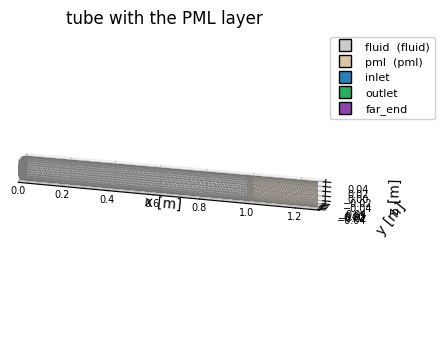

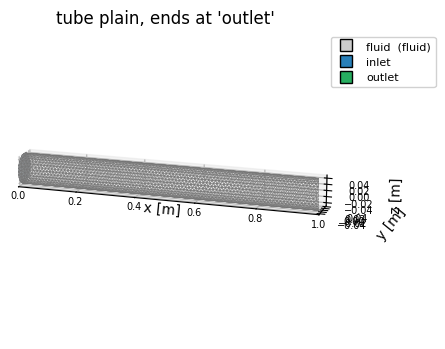

In [2]:
def build_tube(path, h, with_layer):
    gmsh.initialize()
    try:
        gmsh.option.setNumber("General.Terminal", 0)
        gmsh.model.add("tube")
        occ = gmsh.model.occ

        occ.addCylinder(0, 0, 0, L_PHYS, 0, 0, R)
        if with_layer:
            occ.addCylinder(L_PHYS, 0, 0, L_PML, 0, 0, R)
            occ.fragment([(3, 1)], [(3, 2)])
        occ.synchronize()

        volumes = gmsh.model.getEntities(3)
        fluid = [t for _, t in volumes
                 if occ.getCenterOfMass(3, t)[0] < L_PHYS - 1e-9]
        layer = [t for _, t in volumes if t not in fluid]
        gmsh.model.addPhysicalGroup(3, fluid, name="fluid")
        if layer:
            gmsh.model.addPhysicalGroup(3, layer, name="pml")

        faces = [(0.0, "inlet"), (L_PHYS, "outlet")]
        if with_layer:
            faces.append((L_PHYS + L_PML, "far_end"))
        for x_face, name in faces:
            tags = [t for _, t in gmsh.model.getEntities(2)
                    if abs(occ.getCenterOfMass(2, t)[0] - x_face) < 1e-6]
            gmsh.model.addPhysicalGroup(2, tags, name=name)

        gmsh.option.setNumber("Mesh.MeshSizeMax", h)
        gmsh.model.mesh.generate(3)
        gmsh.option.setNumber("Mesh.MshFileVersion", 2.2)
        gmsh.write(str(path))
    finally:
        gmsh.finalize()
    return path


WORK = pathlib.Path(tempfile.mkdtemp())
H_COARSE = element_size_for(C0, F_PLANE_TOP, OVERSHOOT * N_LAMBDA)
print(f"target element size {H_COARSE * 1e3:.1f} mm "
      f"(for {N_LAMBDA} measured elements per wavelength at "
      f"{F_PLANE_TOP:.0f} Hz)")

mesh_pml = load_mesh_with_groups(
    str(build_tube(WORK / "tube_pml.msh", H_COARSE, with_layer=True))
)
mesh_som = load_mesh_with_groups(
    str(build_tube(WORK / "tube_som.msh", H_COARSE, with_layer=False))
)

for label, mesh in (("with layer", mesh_pml), ("plain", mesh_som)):
    nodes, _, boundaries, groups = mesh
    counts = {g: sum(c.shape[0] for c in groups[g]["elements"].values())
              for g in groups}
    print(f"{label:11s}: {nodes.shape[0]:5d} nodes, groups {counts}, "
          f"faces {list(boundaries)}")

print()
print(validate_mesh(str(WORK / "tube_som.msh"), c0=C0, f_max=F_PLANE_TOP))

# Look at both before solving on either: the layer is the only difference,
# and it has to sit at the far end of the fluid, sharing its face with it.
for label, mesh in (("with the PML layer", mesh_pml),
                    ("plain, ends at 'outlet'", mesh_som)):
    plot_geometry(mesh[0], mesh[3], title=f"tube {label}",
                  elev=16, azim=-72, figsize=(9.0, 3.6))

## 2. The two models

Both are driven the same way: a normal velocity on the inlet, plus a radiation
condition on that same face so the inlet does not act as a mirror. The models
differ only in what closes the far end.

| | domain | far end |
|---|---|---|
| **PML** | fluid + layer | absorbed inside the layer; the last face never matters |
| **Sommerfeld** | fluid | `add_anechoic("outlet")`, i.e. $\zeta = 1$ |

`prepare_acoustic_system` builds the layer by itself when the mesh has a `pml`
group; the `pml=` argument only passes options to it. On the plain mesh there
is no such group and nothing is built.

In [3]:
V_PISTON = 1.0


def solve(mesh, bc, frequencies, pml_options=None):
    """Prepare and sweep, returning the full nodal pressure and the timings."""
    nodes, elements, boundaries, groups = mesh

    t0 = time.perf_counter()
    system = pycafe.prepare_acoustic_system(
        nodes=nodes, elements=elements, boundaries=boundaries,
        rho=RHO, c0=C0, bc=bc, groups=groups, pml=pml_options,
    )
    t_prepare = time.perf_counter() - t0

    t0 = time.perf_counter()
    P_red = solve_helmholtz_frequency_sweep(
        K_red=system["K_red"], M_red=system["M_red"], C_red=system["C_red"],
        frequencies=frequencies,
        pressure_nodes_red=system["pressure_nodes_red"],
        pressure_values=system["pressure_values"],
        nodes=nodes, idx_free=system["idx_free"], rho=RHO,
        boundaries=boundaries, elements=elements, groups=groups,
        boundary_dim=system["boundary_dim"],
        velocity_operator=system["velocity_red_op"],
        impedance_operator=system["C_red_op"],
        source_operator=system["source_red_op"],
        pml_operator=system["pml_red_op"],
    )
    t_sweep = time.perf_counter() - t0

    p = np.zeros((nodes.shape[0], len(frequencies)), dtype=complex)
    p[system["idx_free"], :] = P_red
    return p, system, t_prepare, t_sweep


def drive():
    return AcousticBC().add_velocity("inlet", -V_PISTON).add_anechoic("inlet")


bc_pml = drive()
bc_som = drive().add_anechoic("outlet")

## 3. Below the first cross mode: a plane wave

A circular duct carries only the plane wave until the first transverse mode
cuts on at $f_c = \alpha_{11} c_0 / (2\pi R)$, with $\alpha_{11} = 1.8412$.
Below it, everything that reaches the end arrives at **normal incidence** —
precisely the case the plane-wave condition is exact for. So this is the region
where the PML has the least to offer, and it is worth seeing that before seeing
the region where it has the most.

In [4]:
F_CUT = 1.8412 * C0 / (2 * np.pi * R)
print(f"first cross mode cuts on at {F_CUT:.0f} Hz")

freqs_plane = np.linspace(150.0, 1500.0, 40)

p_pml, sys_pml, tp_pml, ts_pml = solve(mesh_pml, bc_pml, freqs_plane,
                                       pml_options={"verbose": True})
p_som, sys_som, tp_som, ts_som = solve(mesh_som, bc_som, freqs_plane)

print(f"\nlayer resolved by {layer_resolution(sys_pml['pml_op'])} elements "
      "across its thickness")
print(f"prepare  PML {tp_pml:.2f} s   Sommerfeld {tp_som:.2f} s")
print(f"sweep    PML {ts_pml:.2f} s   Sommerfeld {ts_som:.2f} s "
      f"({len(freqs_plane)} frequencies)")

first cross mode cuts on at 2010 Hz
Acoustic domain from physical group 'fluid': CTETRA4


PML from group 'pml': box layer ([0.0, -0.05, -0.05] .. [1.0, 0.05, 0.05], fit 0.00e+00), thickness [0.3 0.  0. ], 24 elements across, target reflection 0.0001


Acoustic domain from physical group 'fluid': CTETRA4



layer resolved by 24 elements across its thickness
prepare  PML 1.09 s   Sommerfeld 0.53 s
sweep    PML 5.13 s   Sommerfeld 1.82 s (40 frequencies)


### Reading the reflection off the field

A duct carrying one mode holds a forward and a backward wave,
$p(x) = A e^{-ikx} + B e^{+ikx}$. Fitting both amplitudes to the computed
pressure on the axis gives $|B/A|$: what the termination sent back. It is a
sharper measure than the ripple of $|p|$, which mixes reflection with the
numerical dispersion of the mesh.

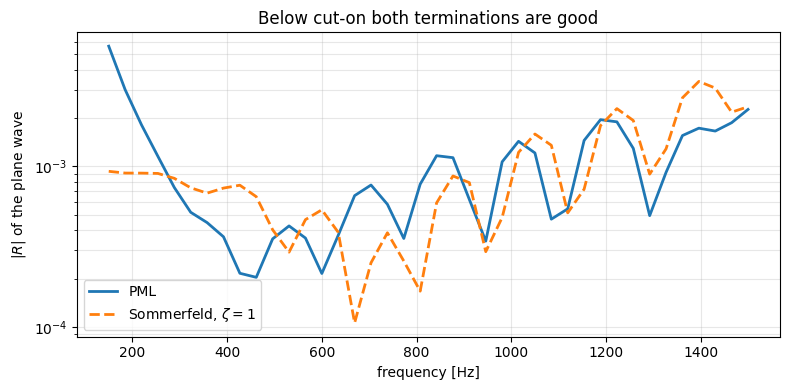

median |R|   PML 0.0008   Sommerfeld 0.0008


In [5]:
def axis_nodes(nodes, x_min=0.0, x_max=None):
    x_max = L_PHYS - 1e-9 if x_max is None else x_max
    sel = np.where((np.hypot(nodes[:, 1], nodes[:, 2]) < 0.4 * R)
                   & (nodes[:, 0] > x_min) & (nodes[:, 0] < x_max))[0]
    return sel[np.argsort(nodes[sel, 0])]


def plane_reflection(nodes, p, i, freq, probe):
    k = 2 * np.pi * freq / C0
    x = nodes[probe, 0]
    basis = np.column_stack([np.exp(-1j * k * x), np.exp(1j * k * x)])
    coefficients, *_ = np.linalg.lstsq(basis, p[probe, i], rcond=None)
    return abs(coefficients[1] / coefficients[0])


probe_pml = axis_nodes(mesh_pml[0])
probe_som = axis_nodes(mesh_som[0])

R_pml = np.array([plane_reflection(mesh_pml[0], p_pml, i, f, probe_pml)
                  for i, f in enumerate(freqs_plane)])
R_som = np.array([plane_reflection(mesh_som[0], p_som, i, f, probe_som)
                  for i, f in enumerate(freqs_plane)])

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(freqs_plane, R_pml, "-", lw=2, label="PML")
ax.semilogy(freqs_plane, R_som, "--", lw=2, label=r"Sommerfeld, $\zeta=1$")
ax.set(xlabel="frequency [Hz]", ylabel="$|R|$ of the plane wave",
       title="Below cut-on both terminations are good")
ax.grid(alpha=0.3, which="both")
ax.legend()
plt.tight_layout()
plt.show()

print(f"median |R|   PML {np.median(R_pml):.4f}   "
      f"Sommerfeld {np.median(R_som):.4f}")

### What the inlet condition does to the amplitude

Driving a face and making it non-reflecting at the same time is a *soft*
source: the outgoing wave carries half of what a rigid piston of the same
velocity would produce, because the other half leaves through the inlet's own
radiation condition. The value below is measured, not assumed — worth checking
whenever the two conditions share a face.

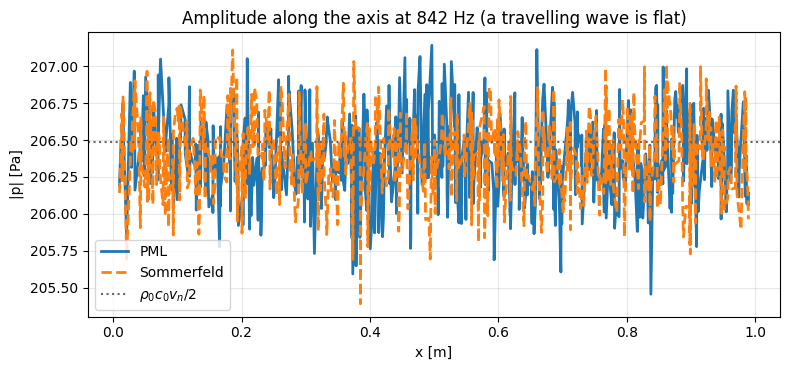

|p| at the inlet: 206.19 Pa   rho c v/2 = 206.49 Pa


In [6]:
i = len(freqs_plane) // 2
f = freqs_plane[i]

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.plot(mesh_pml[0][probe_pml, 0], np.abs(p_pml[probe_pml, i]), lw=2,
        label="PML")
ax.plot(mesh_som[0][probe_som, 0], np.abs(p_som[probe_som, i]), "--", lw=2,
        label="Sommerfeld")
ax.axhline(RHO * C0 * V_PISTON / 2, color="0.4", ls=":",
           label=r"$\rho_0 c_0 v_n / 2$")
ax.set(xlabel="x [m]", ylabel="|p| [Pa]",
       title=f"Amplitude along the axis at {f:.0f} Hz "
             "(a travelling wave is flat)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"|p| at the inlet: {abs(p_pml[probe_pml[0], i]):.2f} Pa   "
      f"rho c v/2 = {RHO * C0 * V_PISTON / 2:.2f} Pa")

### The field in 3D

Left the PML model, right the Sommerfeld one. The layer is drawn too: the
pressure dies inside it, which is the whole point — nothing reaches the last
face, so what that face does no longer matters.

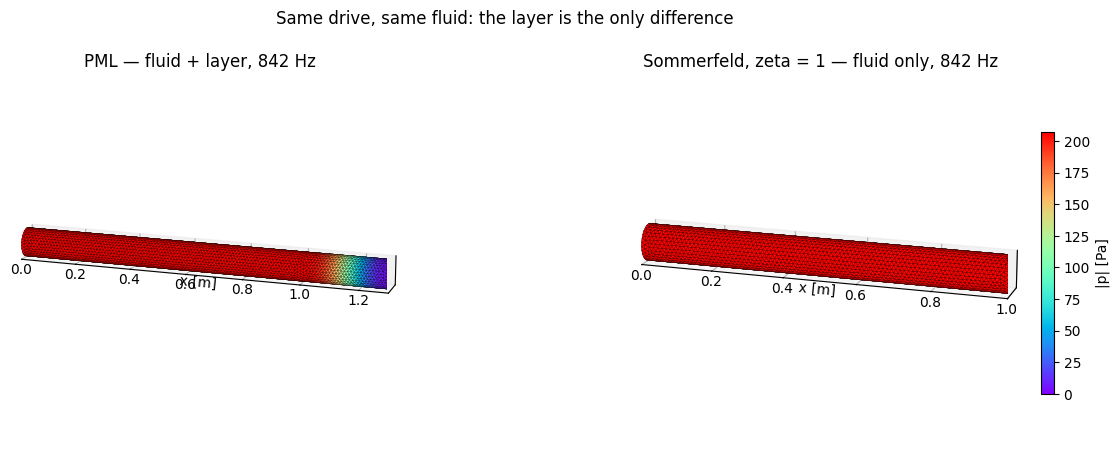

In [7]:
def tube_pair(left, right, index, freq, titles, suptitle):
    """
    Two tubes side by side, on one colour scale.

    A duct is long and thin, so the panels get a shallow view and the
    depth axis loses its ticks: at this aspect ratio they only collide
    with the tube.
    """
    clim = (0.0, max(np.abs(left[2][:, index]).max(),
                     np.abs(right[2][:, index]).max()))

    fig = plt.figure(figsize=(13, 4.6))
    for column, (mesh, p, title) in enumerate(
        ((left[0], left[2], titles[0]), (right[0], right[2], titles[1]))
    ):
        ax = fig.add_subplot(1, 2, column + 1, projection="3d")
        plot_pressure_3d(mesh[0], mesh[1], p[:, index], part="abs",
                         clim=clim, elev=16, azim=-72,
                         colorbar=(column == 1), ax=ax, show=False,
                         title=title)
        ax.set_zticks([])
        ax.set_yticks([])
        ax.set_zlabel("")
        ax.set_ylabel("")
    fig.suptitle(suptitle, y=0.99)
    plt.tight_layout()
    plt.show()


tube_pair((mesh_pml, None, p_pml), (mesh_som, None, p_som), i, f,
          (f"PML — fluid + layer, {f:.0f} Hz",
           f"Sommerfeld, zeta = 1 — fluid only, {f:.0f} Hz"),
          "Same drive, same fluid: the layer is the only difference")

## 4. Above cut-on: where the two part company

Past $f_c$ the duct carries a second mode, and that mode travels at an angle:
its axial wavenumber is $k_x = \sqrt{k^2 - (\alpha_{11}/R)^2}$, so it meets the
end face at $\cos\theta = k_x / k < 1$.

The plane-wave condition assumes $\cos\theta = 1$. For a wave arriving at
$\theta$, an impedance $\zeta = 1$ reflects

$$|R| = \left|\frac{\cos\theta - 1}{\cos\theta + 1}\right| ,$$

which is no longer small. The PML carries no such assumption: it absorbs along
the direction it is stretched in, whatever the field does in the other two.

To excite the mode, the source goes **off axis**. The mesh is refined, since
these frequencies are shorter.

In [8]:
H_FINE = element_size_for(C0, F_MODAL_TOP, OVERSHOOT * N_LAMBDA)
print(f"target element size {H_FINE * 1e3:.1f} mm (for {N_LAMBDA} measured "
      f"elements per wavelength at {F_MODAL_TOP:.0f} Hz)")
mesh_pml_f = load_mesh_with_groups(
    str(build_tube(WORK / "fine_pml.msh", H_FINE, with_layer=True))
)
mesh_som_f = load_mesh_with_groups(
    str(build_tube(WORK / "fine_som.msh", H_FINE, with_layer=False))
)
print(f"refined: {mesh_pml_f[0].shape[0]} and {mesh_som_f[0].shape[0]} nodes")

SOURCE = np.array([0.25, 0.6 * R, 0.0])            # off the axis on purpose
freqs_modal = np.array([1500.0, 2200.0, 2500.0, 2800.0, 3200.0])


def monopole():
    return AcousticBC().add_monopole(1e-3, position=SOURCE)


p_pml_f, sys_pml_f, _, ts_pml_f = solve(
    mesh_pml_f, monopole(), freqs_modal, pml_options={"verbose": False}
)
p_som_f, sys_som_f, _, ts_som_f = solve(
    mesh_som_f, monopole().add_anechoic("outlet"), freqs_modal
)

print(f"sweep    PML {ts_pml_f:.2f} s   Sommerfeld {ts_som_f:.2f} s")

target element size 5.4 mm (for 10 measured elements per wavelength at 3200 Hz)


Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmppu6k6wqm/fine_pml.msh'...
Info    : 57657 nodes
Info    : 307394 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmppu6k6wqm/fine_pml.msh'


→ Triangle 3      | Dim: 2 | Order: 1 | Nodes/Elem: 3 | Count: 2005
→ Tetrahedron 4   | Dim: 3 | Order: 1 | Nodes/Elem: 4 | Count: 305389


Info    : Reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmppu6k6wqm/fine_som.msh'...
Info    : 44443 nodes
Info    : 236194 elements
Info    : Done reading '/var/folders/pk/hzqdb22d0rj05nltl9btt7640000gn/T/tmppu6k6wqm/fine_som.msh'
→ Triangle 3      | Dim: 2 | Order: 1 | Nodes/Elem: 3 | Count: 1338


→ Tetrahedron 4   | Dim: 3 | Order: 1 | Nodes/Elem: 4 | Count: 234856
refined: 57657 and 44443 nodes
Acoustic domain from physical group 'fluid': CTETRA4


Acoustic domain from physical group 'fluid': CTETRA4


sweep    PML 16.49 s   Sommerfeld 11.03 s


In [9]:
ALPHA = 1.8412


def modal_reflection(nodes, p, i, freq, x0=0.35, x1=0.90, n_bins=26):
    """
    Reflection of the first cross mode, from a projection onto its shape.

    The transverse shape J1(alpha r/R) cos(theta) is projected out of the
    field in slabs along x, giving the modal amplitude a(x); forward and
    backward waves are then fitted with the **axial** wavenumber, which is
    what makes this different from the plane-wave fit above.
    """
    k = 2 * np.pi * freq / C0
    k_t = ALPHA / R
    if k <= k_t:
        return None, None
    k_x = np.sqrt(k ** 2 - k_t ** 2)

    r = np.hypot(nodes[:, 1], nodes[:, 2])
    theta = np.arctan2(nodes[:, 2], nodes[:, 1])
    shape = jv(1, ALPHA * r / R) * np.cos(theta)

    edges = np.linspace(x0, x1, n_bins + 1)
    xs, amplitudes = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        sel = np.where((nodes[:, 0] >= lo) & (nodes[:, 0] < hi))[0]
        weight = shape[sel]
        if sel.size < 8 or np.dot(weight, weight) < 1e-9:
            continue
        xs.append(nodes[sel, 0].mean())
        amplitudes.append(np.dot(weight, p[sel, i]) / np.dot(weight, weight))

    xs = np.array(xs)
    basis = np.column_stack([np.exp(-1j * k_x * xs), np.exp(1j * k_x * xs)])
    coefficients, *_ = np.linalg.lstsq(basis, np.array(amplitudes), rcond=None)
    return abs(coefficients[1] / coefficients[0]), k_x / k


rows = []
for i, f in enumerate(freqs_modal):
    r_pml, cos_theta = modal_reflection(mesh_pml_f[0], p_pml_f, i, f)
    r_som, _ = modal_reflection(mesh_som_f[0], p_som_f, i, f)
    predicted = (None if cos_theta is None
                 else abs(cos_theta - 1.0) / (cos_theta + 1.0))
    rows.append((f, cos_theta, r_pml, r_som, predicted))

head = (f"{'f [Hz]':>8}{'cos(theta)':>12}{'|R| PML':>10}"
        f"{'|R| Somm':>10}{'theory':>9}")
print(head)
print("-" * len(head))
for f, cos_theta, r_pml, r_som, predicted in rows:
    if cos_theta is None:
        print(f"{f:>8.0f}{'below cut-on':>14}")
        continue
    print(f"{f:>8.0f}{cos_theta:>12.3f}{r_pml:>10.3f}{r_som:>10.3f}"
          f"{predicted:>9.3f}")

  f [Hz]  cos(theta)   |R| PML  |R| Somm   theory
-------------------------------------------------
    1500  below cut-on
    2200       0.406     0.017     0.419    0.422
    2500       0.595     0.006     0.252    0.254
    2800       0.696     0.005     0.180    0.179
    3200       0.778     0.005     0.119    0.125


The last column is the closed form for an impedance $\zeta = 1$ meeting a wave
at angle $\theta$. The measured Sommerfeld reflection follows it — the
condition is not misbehaving, it is doing exactly what it promises, and the
promise only covers normal incidence. The PML, on the same mesh and with the
same source, does not depend on the angle that way.

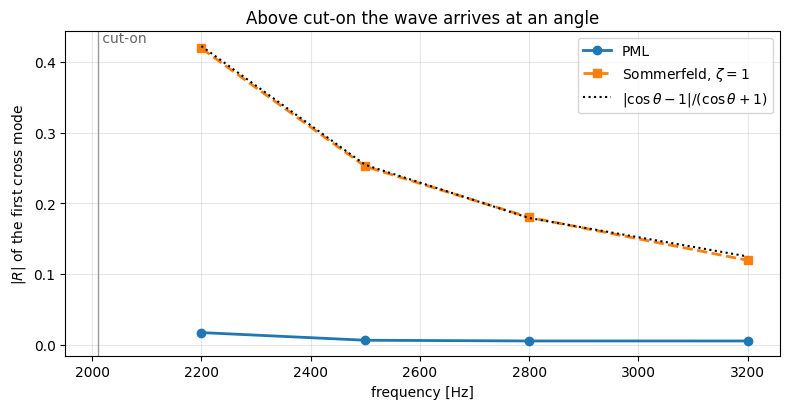

In [10]:
valid = [row for row in rows if row[1] is not None]
f_valid = [row[0] for row in valid]

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(f_valid, [row[2] for row in valid], "o-", lw=2, label="PML")
ax.plot(f_valid, [row[3] for row in valid], "s--", lw=2,
        label=r"Sommerfeld, $\zeta=1$")
ax.plot(f_valid, [row[4] for row in valid], "k:", lw=1.5,
        label=r"$|\cos\theta-1|/(\cos\theta+1)$")
ax.axvline(F_CUT, color="0.6", lw=1)
ax.text(F_CUT, ax.get_ylim()[1], " cut-on", va="top", color="0.4")
ax.set(xlabel="frequency [Hz]", ylabel="$|R|$ of the first cross mode",
       title="Above cut-on the wave arrives at an angle")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### The two fields above cut-on

Left the PML, right the Sommerfeld condition, at a frequency well above the
cut-on. What the reflection number says shows up here as the interference the
reflected mode leaves behind in the fluid.

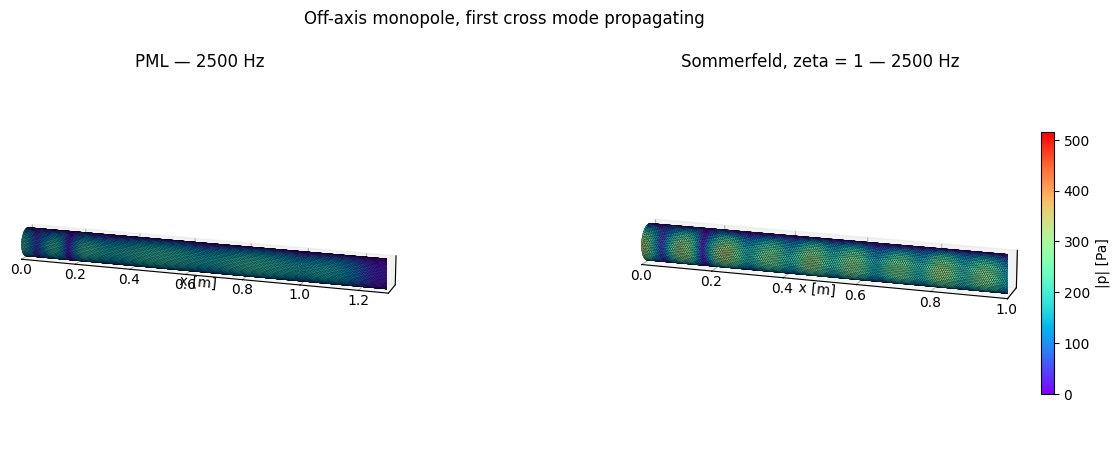

In [11]:
j = int(np.argmin(np.abs(freqs_modal - 2500.0)))

tube_pair((mesh_pml_f, None, p_pml_f), (mesh_som_f, None, p_som_f), j,
          freqs_modal[j],
          (f"PML — {freqs_modal[j]:.0f} Hz",
           f"Sommerfeld, zeta = 1 — {freqs_modal[j]:.0f} Hz"),
          "Off-axis monopole, first cross mode propagating")

## 5. What it costs

The PML solves a bigger system — the layer's nodes are unknowns like any
other — and rebuilds its block at every frequency, since the stretching depends
on $\omega$. The plane-wave condition adds one boundary matrix and no unknowns.

In [12]:
n_pml = mesh_pml_f[3]["pml"]["elements"]["Tetrahedron 4"].shape[0]
n_fluid = mesh_pml_f[3]["fluid"]["elements"]["Tetrahedron 4"].shape[0]
n_som = mesh_som_f[3]["fluid"]["elements"]["Tetrahedron 4"].shape[0]

print(f"{'':14}{'unknowns':>10}{'elements':>10}{'sweep [s]':>12}")
print("-" * 46)
print(f"{'PML':14}{sys_pml_f['K_red'].shape[0]:>10}"
      f"{n_fluid + n_pml:>10}{ts_pml_f:>12.2f}")
print(f"{'Sommerfeld':14}{sys_som_f['K_red'].shape[0]:>10}"
      f"{n_som:>10}{ts_som_f:>12.2f}")
print(f"\nthe layer adds {n_pml} elements to {n_fluid} of fluid")

                unknowns  elements   sweep [s]
----------------------------------------------
PML                57657    305389       16.49
Sommerfeld         44443    234856       11.03

the layer adds 70599 elements to 234790 of fluid


## What to take away

* **Below cut-on the plane-wave condition is the right tool.** The wave meets
  the end face head on, which is the case $\zeta = 1$ is derived for, and the
  layer buys nothing for its extra unknowns.
* **Above cut-on it reflects, by a predictable amount.** The measured
  reflection follows $|\cos\theta - 1| / (\cos\theta + 1)$: the condition is
  not failing, it is being used outside its assumption.
* **The PML carries no such assumption.** It absorbs along the direction it is
  stretched in, so an oblique mode is absorbed much like a normal one.
* **The mesh is the interface.** A physical group named `pml` is the entire
  switch; its shape, its interface and its thickness are measured from the two
  groups. Delete the group and the model is an ordinary one again.

Two things this notebook does not settle: how thick the layer should be, and
how much absorption to ask of it. `target_reflection` is the one number that
cannot come from the mesh, and `layer_resolution` reports how many elements the
profile has to climb over — a layer too coarse for the absorption asked of it
reflects off its own steps.